In [3]:
import sys
import pandas as pd
sys.path.append('../') 

from src.data_loader import TimeSeriesDataLoader

loader = TimeSeriesDataLoader()

file_path = '../data/raw/Internal Submission Hourly 2024.csv' 
df = loader.load_and_clean(file_path)

feature_cols = [
    'Carbon intensity gCO₂eq/kWh (direct)', 
    'Carbon-free energy percentage (CFE%)', 
    'Renewable energy percentage (RE%)'
]

train_df, test_df = loader.split_and_scale(df, feature_cols=feature_cols, train_ratio=0.8)

look_back = 24       # Menggunakan histori 24 jam ke belakang
forecast_horizon = 1 # Memprediksi 1 jam ke depan

print("\nCreating sliding windows...")
X_train, y_train = loader.create_sliding_window(train_df, look_back, forecast_horizon)
X_test, y_test = loader.create_sliding_window(test_df, look_back, forecast_horizon)

#(Sanity Check)
print("\n--- Hasil Dimensi Array ---")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Loading data from ../data/raw/Internal Submission Hourly 2024.csv...
Data cleaned. Total baris: 8784
Splitting and Scaling data...

Creating sliding windows...

--- Hasil Dimensi Array ---
X_train shape: (7003, 24, 3)
y_train shape: (7003, 1)
X_test shape: (1733, 24, 3)
y_test shape: (1733, 1)


In [4]:
X_train_uni = X_train[:, :, 0:1]
X_test_uni = X_test[:, :, 0:1]

print("Shape Univariate Train:", X_train_uni.shape)
print("Shape Univariate Test:", X_test_uni.shape)

Shape Univariate Train: (7003, 24, 1)
Shape Univariate Test: (1733, 24, 1)


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model_uni = Sequential([
    LSTM(units=64, return_sequences=False, input_shape=(look_back, 1)),
    Dropout(0.2),
    # Output Layer (1 karena One-step Ahead)
    Dense(units=1)
])
model_uni.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

model_uni.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('../saved_models/dl_weights/univariate_lstm_best.keras', save_best_only=True)
]

print("\nMemulai Training Model Univariate LSTM...")
history_uni = model_uni.fit(
    X_train_uni, y_train,
    validation_data=(X_test_uni, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)


Memulai Training Model Univariate LSTM...
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0172 - mae: 0.0991 - val_loss: 0.0113 - val_mae: 0.0869
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0102 - mae: 0.0801 - val_loss: 0.0084 - val_mae: 0.0727
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0083 - mae: 0.0720 - val_loss: 0.0063 - val_mae: 0.0623
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0071 - mae: 0.0665 - val_loss: 0.0051 - val_mae: 0.0562
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0061 - mae: 0.0613 - val_loss: 0.0046 - val_mae: 0.0534
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - mae: 0.0595 - val_loss: 0.0042 - val_mae: 0.0507
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0052 - mae: 0.0566 - val_loss: 0.0038 - val_mae: 0.0476
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0049 - mae: 0.0545 - val_loss: 0.0036 - val_mae: 0.0462
Epoch 9/50
21

melakukan prediksi...
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- Hasil Evaluasi (Skala gCO_2eq/kWh) ---
MAE  : 2.52
RMSE : 3.32
MAPE : 0.44%


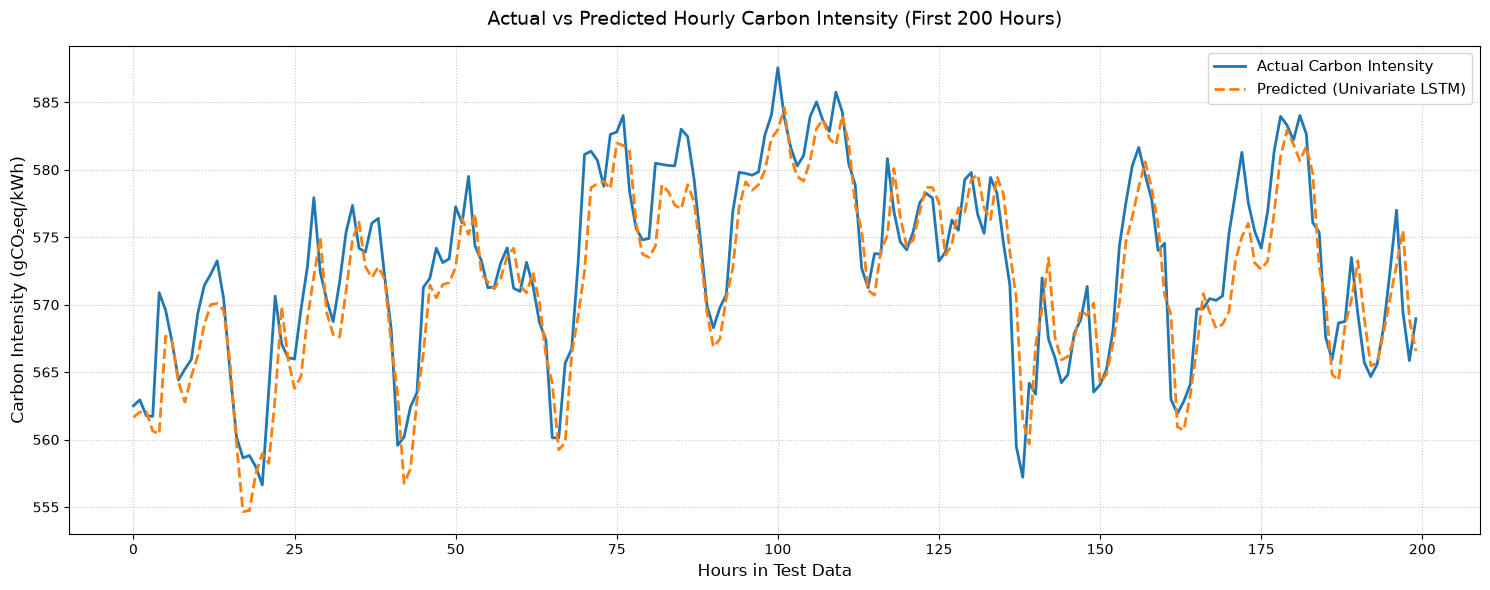

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("melakukan prediksi...")
y_pred_scaled = model_uni.predict(X_test_uni)

y_test_asli = loader.target_scaler.inverse_transform(y_test)
y_pred_asli = loader.target_scaler.inverse_transform(y_pred_scaled)

# Hitung Metrik Evaluasi
mae = mean_absolute_error(y_test_asli, y_pred_asli)
rmse = np.sqrt(mean_squared_error(y_test_asli, y_pred_asli))
mape = np.mean(np.abs((y_test_asli - y_pred_asli) / y_test_asli)) * 100

print("\n--- Hasil Evaluasi (Skala gCO_2eq/kWh) ---")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# Visualisasi (Plotting)
# plot 200 jam pertama agar fluktuasinya terlihat jelas
plot_hours = 200

plt.figure(figsize=(15, 6))
plt.plot(y_test_asli[:plot_hours], label='Actual Carbon Intensity', color='#1f77b4', linewidth=2)
plt.plot(y_pred_asli[:plot_hours], label='Predicted (Univariate LSTM)', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('Actual vs Predicted Hourly Carbon Intensity (First 200 Hours)', fontsize=14, pad=15)
plt.xlabel('Hours in Test Data', fontsize=12)
plt.ylabel('Carbon Intensity (gCO₂eq/kWh)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Merapikan layout
plt.tight_layout()
plt.show()